In [3]:
import pandas as pd

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

In [5]:
df = pd.read_csv("../data/raw/google_trends_raw.csv")

In [6]:
df.head()

,Time,Zomato,Swiggy
0,2021-08-01,100,41
1,2021-09-01,75,39
2,2021-10-01,58,39
3,2021-11-01,64,41
4,2021-12-01,57,43


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Time    61 non-null     str  
 1   Zomato  61 non-null     int64
 2   Swiggy  61 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.6 KB


In [8]:
df.describe()

,Zomato,Swiggy
count,61.000000,61.000000
mean,58.229508,43.000000
std,13.329658,7.028513
min,37.000000,34.000000
25%,48.000000,39.000000
50%,58.000000,41.000000
75%,66.000000,44.000000
max,100.000000,83.000000


In [9]:
df.isnull().sum()

Time      0
Zomato    0
Swiggy    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Time', 'Zomato', 'Swiggy'], dtype='str')

In [12]:
df["Time"] = pd.to_datetime(df["Time"])

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Time    61 non-null     datetime64[us]
 1   Zomato  61 non-null     int64         
 2   Swiggy  61 non-null     int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 1.6 KB


In [14]:
df = df.sort_values(by="Time")

In [15]:
df.reset_index(drop=True, inplace=True)

In [16]:
df.set_index("Time", inplace=True)

In [17]:
df.head()

,Zomato,Swiggy
Time,,
2021-08-01,100,41
2021-09-01,75,39
2021-10-01,58,39
2021-11-01,64,41
2021-12-01,57,43


# Exploratory Data Analysis

## Business Question 1

How has the search interest of Zomato and Swiggy changed over time?

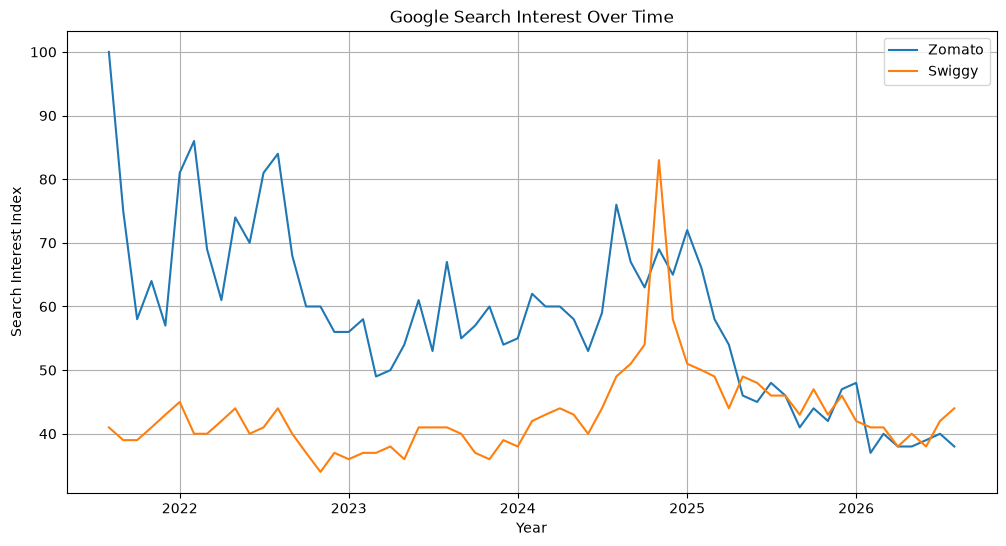

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Zomato"], label="Zomato")
plt.plot(df.index, df["Swiggy"], label="Swiggy")

plt.title("Google Search Interest Over Time")
plt.xlabel("Year")
plt.ylabel("Search Interest Index")

plt.legend()

plt.grid(True)

plt.show()

In [25]:
df.mean()

Zomato    58.229508
Swiggy    43.000000
dtype: float64

In [26]:
df.describe()

,Zomato,Swiggy
count,61.000000,61.000000
mean,58.229508,43.000000
std,13.329658,7.028513
min,37.000000,34.000000
25%,48.000000,39.000000
50%,58.000000,41.000000
75%,66.000000,44.000000
max,100.000000,83.000000


In [27]:
df.idxmax()

Zomato   2021-08-01
Swiggy   2024-11-01
dtype: datetime64[us]

In [28]:
df.idxmin()

Zomato   2026-02-01
Swiggy   2022-11-01
dtype: datetime64[us]

In [29]:
# Assumes 'df' has 'Zomato' and 'Swiggy' columns with a DateTimeIndex (or Month column as index)
# Example setup assuming index contains the month names/dates:

kpi_data = {
    'Metric': [
        'Average Search Interest',
        'Highest Search Interest',
        'Lowest Search Interest',
        'Standard Deviation',
        'Peak Month',
        'Lowest Month'
    ],
    'Zomato': [
        df['Zomato'].mean(),
        df['Zomato'].max(),
        df['Zomato'].min(),
        df['Zomato'].std(),
        df['Zomato'].idxmax(),
        df['Zomato'].idxmin()
    ],
    'Swiggy': [
        df['Swiggy'].mean(),
        df['Swiggy'].max(),
        df['Swiggy'].min(),
        df['Swiggy'].std(),
        df['Swiggy'].idxmax(),
        df['Swiggy'].idxmin()
    ]
}

# Create the summary DataFrame
kpi_df = pd.DataFrame(kpi_data)

# Optional: Round numeric rows for cleaner reporting
kpi_df = kpi_df.round(2)

# Display the table
kpi_df

,Metric,Zomato,Swiggy
0,Average Search Interest,58.229508,43.0
1,Highest Search Interest,100,83
2,Lowest Search Interest,37,34
3,Standard Deviation,13.329658,7.028513
4,Peak Month,2021-08-01 00:00:00,2024-11-01 00:00:00
5,Lowest Month,2026-02-01 00:00:00,2022-11-01 00:00:00


## Business Question 2

Has the gap between Zomato and Swiggy narrowed over time?

In [41]:
# Absolute difference: Positive means Zomato leads; negative means Swiggy leads
df['Search_Interest_Gap'] = df['Zomato'] - df['Swiggy']

# Display the average, max, and min gap
print("Avg Search Interest Gap:", df['Search_Interest_Gap'].mean())
print("Max Search Interest Gap:", df['Search_Interest_Gap'].max())
print("Min Search Interest Gap:", abs(df['Search_Interest_Gap']).min())

Avg Search Interest Gap: 15.229508196721312
Max Search Interest Gap: 59
Min Search Interest Gap: 0


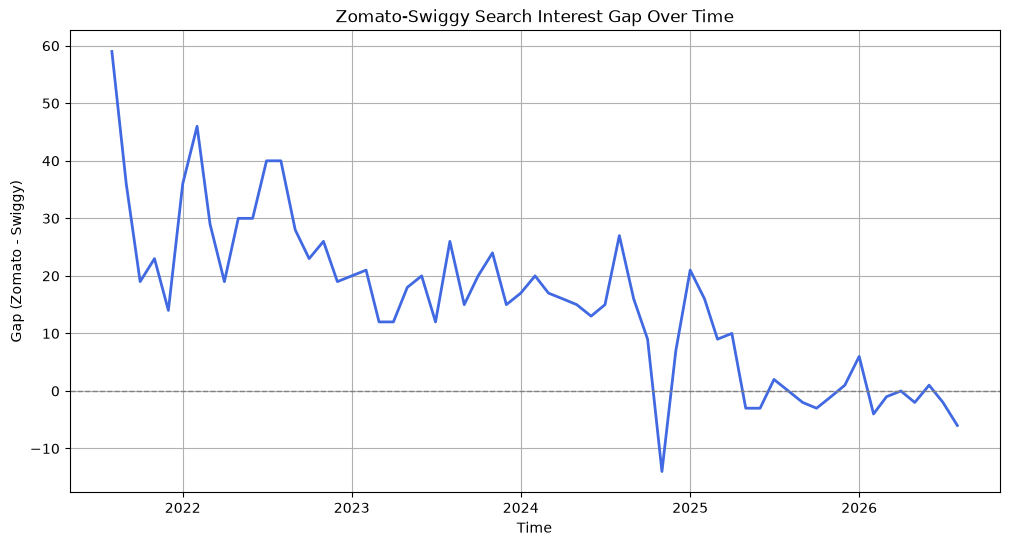

In [42]:
# Create a gap series and plot it over time
df['Search_Interest_Gap'] = df['Zomato'] - df['Swiggy']

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Search_Interest_Gap'], color='royalblue', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Zomato-Swiggy Search Interest Gap Over Time')
plt.xlabel('Time')
plt.ylabel('Gap (Zomato - Swiggy)')
plt.grid(True)
plt.show()

The search interest gap between Zomato and Swiggy has narrowed considerably over the five-year period.